# Load-profile clustering and PCA

Retailers group meters by *how* they use energy across the day: evening-peak households,
daytime businesses, solar exporters. KMeans and PCA are the standard first pass.

Every method is shown first on a handful of points you can check by eye, then on the
real meter-day profiles.

**What's in here**
- KMeans on 6 points in 2-D: labels, centroids, inertia
- why scaling decides what you cluster (size vs shape)
- choosing k: inertia and silhouette
- PCA on a 4 × 2 matrix: components, scores, reconstruction
- GroupKFold on 6 rows: why the split must be by meter
- the real data: meter-day × 48 profiles, clusters you can name
- clustering the meters themselves
- a cluster-centroid forecasting baseline
- checklist

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

pd.set_option("display.width", 120)
pd.set_option("display.max_columns", 60)
np.set_printoptions(precision=3, suppress=True)

## 1. KMeans on six points

Six points in two dimensions, clearly forming two groups.

In [2]:
pts = pd.DataFrame({"x": [1.0, 1.5, 1.2, 8.0, 8.5, 8.2],
                    "y": [1.0, 1.2, 0.8, 8.0, 8.3, 7.9]},
                   index=["p1", "p2", "p3", "p4", "p5", "p6"])
pts

,x,y
p1,1.0,1.0
p2,1.5,1.2
p3,1.2,0.8
p4,8.0,8.0
p5,8.5,8.3
p6,8.2,7.9


In [3]:
from sklearn.cluster import KMeans

km = KMeans(n_clusters=2, n_init=10, random_state=0).fit(pts)
pts["label"] = km.labels_
pts

,x,y,label
p1,1.0,1.0,1
p2,1.5,1.2,1
p3,1.2,0.8,1
p4,8.0,8.0,0
p5,8.5,8.3,0
p6,8.2,7.9,0


Each point gets a label, 0 or 1. The labels are arbitrary integers: a refit could swap
them. What matters is which points are together.

The centroid of a cluster is the mean of its points.

In [4]:
pd.DataFrame(km.cluster_centers_, columns=["x", "y"], index=["centroid 0", "centroid 1"])

,x,y
centroid 0,8.233333,8.066667
centroid 1,1.233333,1.000000


In [5]:
pts.groupby("label")[["x", "y"]].mean()      # same numbers, computed by hand

,x,y
label,,
0,8.233333,8.066667
1,1.233333,1.000000


Inertia is the sum of squared distances from each point to its centroid. Smaller is
tighter.

In [6]:
print("inertia:", round(km.inertia_, 3))
d2 = ((pts[["x", "y"]] - km.cluster_centers_[pts["label"]]) ** 2).sum(axis=1)
print("by hand:", round(d2.sum(), 3))

inertia: 0.42
by hand: 0.42


`predict` assigns a new point to the nearest centroid.

In [7]:
new_point = pd.DataFrame({"x": [7.0], "y": [7.5]})
print("new point goes to cluster", km.predict(new_point)[0])

new point goes to cluster 0


## 2. Scaling decides what you cluster

Two customers with the *same shape* of day (morning and evening bumps) but one is 10×
larger. Without normalising, KMeans separates them by size.

In [8]:
shape = np.array([0.1, 0.3, 0.1, 0.5])           # 4 periods: night, morning, midday, evening
days = pd.DataFrame({
    "small_day1": shape * 1.0,
    "small_day2": shape * 1.1,
    "big_day1":   shape * 10.0,
    "big_day2":   shape * 11.0,
    "flat_day":   [0.25, 0.25, 0.25, 0.25],
}).T
days.columns = ["p1", "p2", "p3", "p4"]
days

,p1,p2,p3,p4
small_day1,0.10,0.30,0.10,0.50
small_day2,0.11,0.33,0.11,0.55
big_day1,1.00,3.00,1.00,5.00
big_day2,1.10,3.30,1.10,5.50
flat_day,0.25,0.25,0.25,0.25


In [9]:
labels_raw = KMeans(n_clusters=2, n_init=10, random_state=0).fit(days).labels_
pd.Series(labels_raw, index=days.index, name="cluster on raw kWh")

small_day1    1
small_day2    1
big_day1      0
big_day2      0
flat_day      1
Name: cluster on raw kWh, dtype: int32

The two big days are alone in one cluster: the split is by size. Divide each row by its
total to keep only the shape.

In [10]:
days_shape = days.div(days.sum(axis=1), axis=0)
days_shape

,p1,p2,p3,p4
small_day1,0.10,0.30,0.10,0.50
small_day2,0.10,0.30,0.10,0.50
big_day1,0.10,0.30,0.10,0.50
big_day2,0.10,0.30,0.10,0.50
flat_day,0.25,0.25,0.25,0.25


In [11]:
labels_shape = KMeans(n_clusters=2, n_init=10, random_state=0).fit(days_shape).labels_
pd.Series(labels_shape, index=days.index, name="cluster on shape")

small_day1    0
small_day2    0
big_day1      0
big_day2      0
flat_day      1
Name: cluster on shape, dtype: int32

Now the four peaked days are together and the flat day is alone: the split is by shape.

## 3. Choosing k

Inertia always falls as k grows (more centroids, shorter distances), so you look for
where it stops falling fast. The silhouette score (between −1 and 1) rewards points
that are close to their own cluster and far from the next one.

In [12]:
from sklearn.metrics import silhouette_score

three_groups = pd.DataFrame({"x": [1, 1.2, 0.9, 5, 5.1, 4.9, 9, 9.2, 8.8],
                             "y": [1, 0.8, 1.1, 5, 5.2, 4.8, 1, 1.2, 0.9]})
rows = []
for k in [2, 3, 4, 5]:
    km_k = KMeans(n_clusters=k, n_init=10, random_state=0).fit(three_groups)
    rows.append({"k": k, "inertia": round(km_k.inertia_, 2),
                 "silhouette": round(silhouette_score(three_groups, km_k.labels_), 3)})
pd.DataFrame(rows).set_index("k")

,inertia,silhouette
k,,
2,47.92,0.633
3,0.32,0.946
4,0.22,0.717
5,0.13,0.530


Inertia drops sharply from k = 2 to k = 3 and barely after; silhouette peaks at k = 3.
The data has three groups.

## 4. PCA on a 4 × 2 matrix

Four observations, two features that move together. PCA finds the direction of most
variance (PC1) and the direction orthogonal to it (PC2).

In [13]:
from sklearn.decomposition import PCA

M = pd.DataFrame({"f1": [1.0, 2.0, 3.0, 4.0], "f2": [1.1, 1.9, 3.2, 3.8]}, index=["o1", "o2", "o3", "o4"])
M

,f1,f2
o1,1.0,1.1
o2,2.0,1.9
o3,3.0,3.2
o4,4.0,3.8


In [14]:
pca = PCA(n_components=2).fit(M)
print("mean of each feature:", pca.mean_)
pd.DataFrame(pca.components_, index=["PC1", "PC2"], columns=["f1", "f2"])

mean of each feature: [2.5 2.5]


,f1,f2
PC1,0.725643,0.688071
PC2,-0.688071,0.725643


PC1 is roughly (0.7, 0.7): "f1 and f2 together". PC2 is the leftover direction.

In [15]:
pd.Series(pca.explained_variance_ratio_, index=["PC1", "PC2"], name="explained variance ratio").round(4)

PC1    0.9954
PC2    0.0046
Name: explained variance ratio, dtype: float64

PC1 explains almost all the variance: the data is essentially one-dimensional.

The **scores** are the coordinates of each observation along the components.

In [16]:
scores = pd.DataFrame(pca.transform(M), index=M.index, columns=["PC1", "PC2"])
scores.round(3)

,PC1,PC2
o1,-2.052,0.016
o2,-0.776,-0.091
o3,0.844,0.164
o4,1.983,-0.089


Score for `o1` along PC1 by hand: (o1 − mean) · PC1.

In [17]:
by_hand = (M.loc["o1"].values - pca.mean_) @ pca.components_[0]
print("o1 score on PC1 by hand:", round(by_hand, 3))

o1 score on PC1 by hand: -2.052


Keeping only PC1 and going back to the original space gives the reconstruction. The
difference is what PC2 was carrying.

In [18]:
pca1 = PCA(n_components=1).fit(M)
recon = pd.DataFrame(pca1.inverse_transform(pca1.transform(M)), index=M.index, columns=M.columns)
pd.concat([M, recon.round(3)], axis=1, keys=["original", "reconstructed from PC1"])

original      reconstructed from PC1       
         f1   f2                     f1     f2
o1      1.0  1.1                  1.011  1.088
o2      2.0  1.9                  1.937  1.966
o3      3.0  3.2                  3.113  3.081
o4      4.0  3.8                  3.939  3.864

## 5. GroupKFold on six rows

Six rows from three meters, two rows each. A plain shuffled split can put one row of a
meter in train and the other in test: the model then "recognises" the meter instead of
learning anything general. `GroupKFold` keeps every meter whole.

In [19]:
from sklearn.model_selection import GroupKFold, KFold

rows6 = pd.DataFrame({"meter": ["A", "A", "B", "B", "C", "C"], "value": [1, 2, 3, 4, 5, 6]})
rows6

,meter,value
0,A,1
1,A,2
2,B,3
3,B,4
4,C,5
5,C,6


In [20]:
for fold, (tr, te) in enumerate(KFold(3, shuffle=True, random_state=0).split(rows6)):
    print(f"KFold      fold {fold}: train rows {tr.tolist()} -> meters {sorted(set(rows6.loc[tr, 'meter']))}   test rows {te.tolist()} -> meters {sorted(set(rows6.loc[te, 'meter']))}")

KFold      fold 0: train rows [0, 1, 3, 4] -> meters ['A', 'B', 'C']   test rows [2, 5] -> meters ['B', 'C']
KFold      fold 1: train rows [0, 2, 4, 5] -> meters ['A', 'B', 'C']   test rows [1, 3] -> meters ['A', 'B']
KFold      fold 2: train rows [1, 2, 3, 5] -> meters ['A', 'B', 'C']   test rows [0, 4] -> meters ['A', 'C']


In [21]:
for fold, (tr, te) in enumerate(GroupKFold(3).split(rows6, groups=rows6["meter"])):
    print(f"GroupKFold fold {fold}: train rows {tr.tolist()} -> meters {sorted(set(rows6.loc[tr, 'meter']))}   test rows {te.tolist()} -> meters {sorted(set(rows6.loc[te, 'meter']))}")

GroupKFold fold 0: train rows [0, 1, 2, 3] -> meters ['A', 'B']   test rows [4, 5] -> meters ['C']
GroupKFold fold 1: train rows [0, 1, 4, 5] -> meters ['A', 'C']   test rows [2, 3] -> meters ['B']
GroupKFold fold 2: train rows [2, 3, 4, 5] -> meters ['B', 'C']   test rows [0, 1] -> meters ['A']


With KFold a meter appears on both sides of the same fold. With GroupKFold each test fold
is one whole meter never seen in training.

## 6. The real data: meter-day × 48 profiles

20 meters, half-hourly, 2023. A compact clean (dedupe, fix the meter-month reported in
Wh, drop the stuck week and incomplete days). The full detection story is in
`05_time_series_research/05`.

In [22]:
raw = pd.read_csv("../data/meter_halfhourly_2023.csv.gz")
meters = pd.read_csv("../data/meters.csv")
df = raw.drop_duplicates().copy()
df["date"] = pd.to_datetime(df["settlement_date"])
print(df.shape)

(349399, 5)


In [23]:
# a meter-month whose median is 100x that meter's other months -> Wh instead of kWh
monthly_median = df.groupby(["meter_id", df["date"].dt.month])["kwh"].median().unstack()
ratio = monthly_median.div(monthly_median.median(axis=1), axis=0)
bad = ratio.stack()
bad = bad[bad > 100]
print(bad.round(0))

meter_id  date
M100007   9       744.0
dtype: float64


In [24]:
for (mid, month) in bad.index:
    m = (df["meter_id"] == mid) & (df["date"].dt.month == month)
    df.loc[m, "kwh"] = df.loc[m, "kwh"] / 1000
per_day = df.groupby(["meter_id", "date"])["kwh"].agg(n="size", nunique="nunique")
keep = per_day[(per_day["n"] == 48) & (per_day["nunique"] > 1)].index    # complete days, not stuck
df = df.set_index(["meter_id", "date"]).loc[keep].reset_index()
print("meter-days kept:", len(keep), "of", len(per_day))

meter-days kept: 6917 of 7286


Pivot to one row per meter-day, one column per period. Then divide each row by its
total absolute energy so only the shape remains (absolute, because solar meters export
and their net total can be near zero).

In [25]:
X_raw = df.pivot_table(index=["meter_id", "date"], columns="settlement_period", values="kwh")
X_raw.columns = [f"p{c:02d}" for c in X_raw.columns]
print(X_raw.shape)
X_raw.iloc[:3, [0, 15, 24, 36, 47]].round(3)

(6917, 48)


p01    p16    p25    p37    p48
meter_id date                                         
M100000  2023-01-01  0.734  0.626  1.993  0.486  0.576
         2023-01-02  0.519  1.000  2.241  0.631  1.000
         2023-01-03  0.931  0.298  3.498  0.753  0.915

In [26]:
gross = X_raw.abs().sum(axis=1)
X_raw = X_raw[gross > 1]
gross = gross[gross > 1]
X_shape = X_raw.div(gross, axis=0)
X_shape.iloc[:3, [0, 15, 24, 36, 47]].round(3)

p01    p16    p25    p37    p48
meter_id date                                         
M100000  2023-01-01  0.010  0.009  0.028  0.007  0.008
         2023-01-02  0.006  0.012  0.028  0.008  0.012
         2023-01-03  0.011  0.004  0.043  0.009  0.011

In [27]:
info = X_raw.index.to_frame(index=False).merge(meters[["meter_id", "customer_type", "has_solar", "tariff"]], on="meter_id", how="left")
info["is_weekend"] = info["date"].dt.dayofweek >= 5
info.index = X_raw.index
info.head(3)

meter_id       date customer_type  has_solar tariff  is_weekend
meter_id date                                                                      
M100000  2023-01-01  M100000 2023-01-01           sme      False  Fixed        True
         2023-01-02  M100000 2023-01-02           sme      False  Fixed       False
         2023-01-03  M100000 2023-01-03           sme      False  Fixed       False

## 7. Clusters you can name

KMeans with k = 3 on the shapes. Look at the composition of each cluster against what
you already know about the meters.

In [28]:
K = 3
km = KMeans(n_clusters=K, n_init=10, random_state=0).fit(X_shape)
labels = pd.Series(km.labels_, index=X_shape.index, name="cluster")
pd.crosstab(labels, [info["customer_type"], info["has_solar"]])

customer_type residential         sme
has_solar           False True  False
cluster                              
0                       0     0  1043
1                    5521   156     0
2                       0   197     0

Plot the three centroids as daily profiles; a cluster you can name is a cluster you can use.

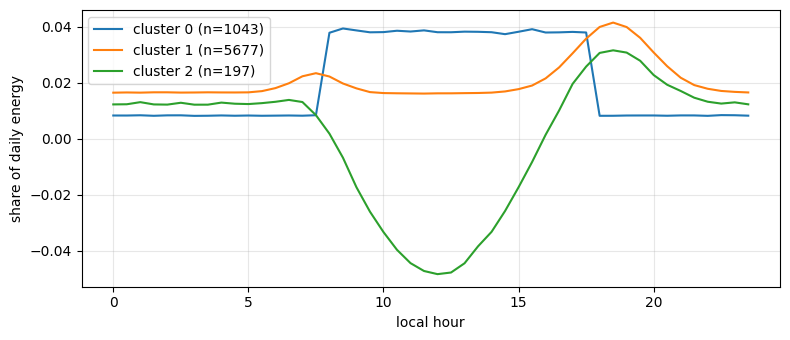

In [29]:
centroids = pd.DataFrame(km.cluster_centers_, columns=X_shape.columns)
hours = np.arange(48) / 2
fig, ax = plt.subplots(figsize=(8, 3.5))
for c in range(K):
    ax.plot(hours, centroids.iloc[c], label=f"cluster {c} (n={int((labels == c).sum())})")
ax.set_xlabel("local hour"); ax.set_ylabel("share of daily energy"); ax.legend(); ax.grid(alpha=.3)
plt.tight_layout()

In [30]:
pd.DataFrame({
    "peak_period": centroids.idxmax(axis=1),
    "evening_share_17_21": centroids.loc[:, "p35":"p42"].sum(axis=1).round(3),
    "daytime_share_09_17": centroids.loc[:, "p19":"p34"].sum(axis=1).round(3),
    "min_value": centroids.min(axis=1).round(4),
})

,peak_period,evening_share_17_21,daytime_share_09_17,min_value
0,p18,0.126,0.613,0.0082
1,p38,0.281,0.283,0.0162
2,p38,0.209,-0.460,-0.0484


A negative minimum means that cluster exports at midday (solar). The daytime-heavy
cluster is the SMEs; the evening-heavy one the households.

Choosing k on the real data: same table as the toy.

In [31]:
rng = np.random.default_rng(0)
sub = rng.choice(len(X_shape), 1500, replace=False)
rows = []
for k in [2, 3, 4, 5, 6]:
    km_k = KMeans(n_clusters=k, n_init=5, random_state=0).fit(X_shape)
    rows.append({"k": k, "inertia": round(km_k.inertia_, 2),
                 "silhouette": round(silhouette_score(X_shape.iloc[sub], km_k.labels_[sub]), 3)})
pd.DataFrame(rows).set_index("k")

,inertia,silhouette
k,,
2,23.93,0.485
3,16.17,0.523
4,15.60,0.123
5,15.17,0.119
6,14.65,0.114


**Pitfall:** silhouette peaks at k = 3 and collapses from k = 4 on, but even the best
value is only about 0.5: real load shapes are a continuum, so expect modest silhouettes
even for a useful k. k = 3 is also the value whose clusters you can name (SME, household,
solar export).

**Interview check:** "Cluster 2 became cluster 0 after a refit, is the model broken?"
No, labels are arbitrary. Compare partitions with the adjusted Rand index, not `==`.

In [32]:
from sklearn.metrics import adjusted_rand_score

a = KMeans(n_clusters=K, n_init=10, random_state=0).fit(X_shape).labels_
b = KMeans(n_clusters=K, n_init=10, random_state=7).fit(X_shape).labels_
print("naive agreement (a == b):", round((a == b).mean(), 3))
print("adjusted Rand index     :", round(adjusted_rand_score(a, b), 3))

naive agreement (a == b): 0.028
adjusted Rand index     : 1.0


## 8. PCA on the real profiles

In [33]:
pca = PCA(n_components=10, random_state=0).fit(X_shape)
evr = pd.Series(pca.explained_variance_ratio_, index=[f"PC{i+1}" for i in range(10)])
pd.DataFrame({"explained": evr.round(3), "cumulative": evr.cumsum().round(3)}).T

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10
explained,0.493,0.111,0.025,0.023,0.022,0.020,0.017,0.016,0.013,0.012
cumulative,0.493,0.604,0.629,0.652,0.674,0.694,0.711,0.727,0.739,0.751


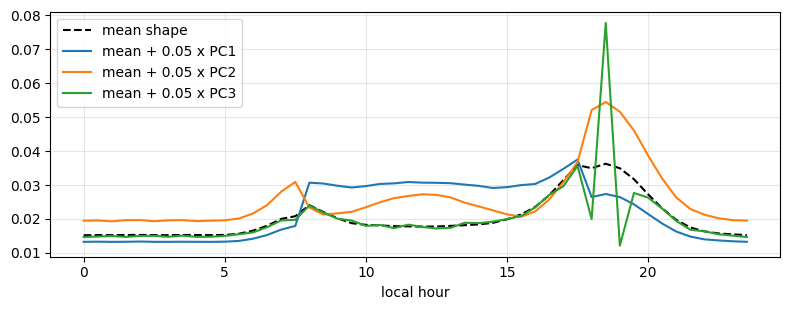

In [34]:
fig, ax = plt.subplots(figsize=(8, 3.2))
ax.plot(hours, pca.mean_, "k--", label="mean shape")
for i in range(3):
    ax.plot(hours, pca.mean_ + 0.05 * pca.components_[i], label=f"mean + 0.05 x PC{i+1}")
ax.set_xlabel("local hour"); ax.legend(); ax.grid(alpha=.3); plt.tight_layout()

Scores by customer type: SMEs and households sit at opposite ends of PC1.

In [35]:
scores = pd.DataFrame(pca.transform(X_shape)[:, :2], index=X_shape.index, columns=["PC1", "PC2"])
scores.join(info[["customer_type", "is_weekend"]]).groupby(["customer_type", "is_weekend"]).mean().round(3)

PC1    PC2
customer_type is_weekend              
residential   False      -0.018  0.005
              True       -0.018  0.005
sme           False       0.105 -0.031
              True        0.092 -0.028

## 9. GroupKFold on the real data

Predict the meter's tariff from PCA scores of its raw kWh profile. Tariff has nothing to
do with load shape, so an honest score should sit at the base rate. A shuffled split lets
the model recognise meters (each has ~340 days and its own size).

In [36]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

Xp = PCA(n_components=5, random_state=0).fit_transform(X_raw)
y = (info["tariff"].fillna("unknown") == "Fixed").astype(int).values
groups = X_shape.index.get_level_values("meter_id")
clf = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000))
acc_shuffled = cross_val_score(clf, Xp, y, cv=KFold(5, shuffle=True, random_state=0))
acc_grouped = cross_val_score(clf, Xp, y, cv=GroupKFold(5), groups=groups)
print("base rate (always 'Fixed'):", round(y.mean(), 3))
print("shuffled KFold accuracy   :", round(acc_shuffled.mean(), 3))
print("GroupKFold by meter       :", round(acc_grouped.mean(), 3))

base rate (always 'Fixed'): 0.601
shuffled KFold accuracy   : 0.624
GroupKFold by meter       : 0.478


The shuffled score is above the base rate only because the model recognises meters. The
grouped score is the honest one. Same logic as chronological splits: the unit of
independence is the meter, not the row.

## 10. Clustering the meters themselves

Average each meter's shape over the year and cluster the 20 meters. Euclidean distance on
raw kWh groups by size; on normalised shapes (or cosine distance) it groups by shape.

In [37]:
from sklearn.cluster import AgglomerativeClustering

meter_shape = X_shape.groupby(level="meter_id").mean()
meter_raw = X_raw.groupby(level="meter_id").mean()
out = meters.set_index("meter_id").loc[meter_shape.index, ["customer_type", "has_solar"]]
out["eucl_on_raw"] = AgglomerativeClustering(n_clusters=3, linkage="average").fit(meter_raw).labels_
out["eucl_on_shape"] = AgglomerativeClustering(n_clusters=3, linkage="average").fit(meter_shape).labels_
out["cosine_on_raw"] = AgglomerativeClustering(n_clusters=3, metric="cosine", linkage="average").fit(meter_raw).labels_
out.sort_values(["customer_type", "eucl_on_shape"])

,customer_type,has_solar,eucl_on_raw,eucl_on_shape,cosine_on_raw
meter_id,,,,,
M100013,residential,True,0,1,1
M100001,residential,False,0,2,0
M100002,residential,False,0,2,0
M100003,residential,False,0,2,0
M100004,residential,False,0,2,0
M100005,residential,False,0,2,0
M100006,residential,False,0,2,0
M100007,residential,False,0,2,0
M100008,residential,False,0,2,0


## 11. A cluster-centroid forecasting baseline

Tomorrow's shape = the centroid of today's cluster, scaled by today's total. Compare with
"same as yesterday" on December.

In [38]:
dates = X_shape.index.get_level_values("date")
train_mask = dates < "2023-12-01"
km_tr = KMeans(n_clusters=K, n_init=10, random_state=0).fit(X_shape[train_mask])
cent = km_tr.cluster_centers_

mae_cluster, mae_naive, n = 0.0, 0.0, 0
for mid, d in X_raw.index[~train_mask]:
    prev = (mid, d - pd.Timedelta(days=1))
    if prev not in X_raw.index:
        continue
    y_true = X_raw.loc[(mid, d)].values
    y_prev = X_raw.loc[prev].values
    c = km_tr.predict(X_shape.loc[[prev]])[0]
    y_cluster = cent[c] * np.abs(y_prev).sum()
    mae_cluster += np.abs(y_true - y_cluster).mean()
    mae_naive += np.abs(y_true - y_prev).mean()
    n += 1
print(f"December, {n} meter-days")
print("MAE cluster centroid :", round(mae_cluster / n, 4))
print("MAE same as yesterday:", round(mae_naive / n, 4))

December, 568 meter-days
MAE cluster centroid : 0.1372
MAE same as yesterday: 0.1864


The centroid averages out one day's noise while keeping the shape. Still a baseline: a
real model would use the cluster as a feature next to lags and calendar.

## Checklist

| Question | Answer |
|---|---|
| what did I cluster, size or shape? | normalise rows for shape; standardise columns for both |
| how did I pick k? | inertia elbow + silhouette on a subsample; name each centroid |
| are labels stable? | compare refits with ARI, never `==` |
| is the split honest? | `GroupKFold(groups=meter_id)` |
| did dirty data get in? | dedupe, unit faults, stuck days, incomplete days first |
| how many shapes are there? | PCA explained variance; components as profiles |
| what do I do with a cluster? | `predict` new days, centroid baseline, segment products |